# Level 1 · Task 1 — Data Preprocessing for Machine Learning
### Codveda Technologies — Machine Learning Internship
**Intern:** Mouhamed Diop · **ID:** CV/A1/79278

---
**Goal:** Transform a raw dataset into a clean, model-ready form by:
1. Loading & exploring the data
2. Handling missing values
3. Encoding categorical variables
4. Scaling numerical features
5. Splitting into training & testing sets

**Dataset:** Telecom customer churn (`churn_train.csv`) — predict whether a customer leaves (`Churn`).
**Tools:** Python, pandas, scikit-learn.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load & Explore the Data
Before touching anything, we look at the shape, column types, summary statistics,
missing values, and the balance of the target variable.

In [2]:
df = pd.read_csv("../../data/churn_train.csv")
print("Shape:", df.shape)
df.head()

Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [4]:
# Summary statistics of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Account length,2666.0,100.620405,39.563974,1.00,73.0000,100.00,127.000,243.00
Area code,2666.0,437.438860,42.521018,408.00,408.0000,415.00,510.000,510.00
Number vmail messages,2666.0,8.021755,13.612277,0.00,0.0000,0.00,19.000,50.00
Total day minutes,2666.0,179.481620,54.210350,0.00,143.4000,179.95,215.900,350.80
Total day calls,2666.0,100.310203,19.988162,0.00,87.0000,101.00,114.000,160.00
Total day charge,2666.0,30.512404,9.215733,0.00,24.3800,30.59,36.700,59.64
Total eve minutes,2666.0,200.386159,50.951515,0.00,165.3000,200.90,235.100,363.70
Total eve calls,2666.0,100.023631,20.161445,0.00,87.0000,100.00,114.000,170.00
Total eve charge,2666.0,17.033072,4.330864,0.00,14.0500,17.08,19.980,30.91
Total night minutes,2666.0,201.168942,50.780323,43.70,166.9250,201.15,236.475,395.00


Churn
False    2278
True      388
Name: count, dtype: int64

Churn rate: 14.6%


/sessions/funny-affectionate-tesla/tmp/ipykernel_7/3792896770.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, palette="viridis")


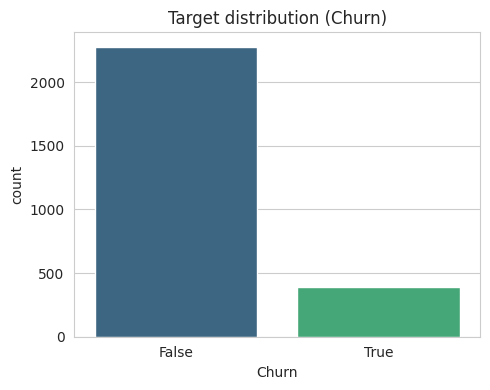

In [5]:
# Target variable balance
target = "Churn"
print(df[target].value_counts())
print("\nChurn rate: {:.1%}".format(df[target].mean()))

plt.figure(figsize=(5,4))
sns.countplot(x=target, data=df, palette="viridis")
plt.title("Target distribution (Churn)")
plt.tight_layout()
plt.savefig("output_churn_distribution.png", dpi=110)
plt.show()

**Observation:** The dataset has 2666 rows and 20 columns. The target `Churn` is
**imbalanced** (~15% churn) — important to remember for modeling (use stratified split,
and metrics beyond accuracy).

## Step 2 — Handle Missing Data
First we check for missing values. This dataset is clean (0 missing), so to **demonstrate**
the imputation technique we inject a small amount of synthetic missing values into a copy,
then fill them: **median** for numerical columns and **most frequent** for categorical ones.

In [6]:
print("Missing values per column (original):")
print(df.isnull().sum().sum(), "total missing values")

Missing values per column (original):
0 total missing values


In [7]:
# --- Demonstration of imputation on a synthetic copy ---
rng = np.random.default_rng(42)
df_demo = df.copy()

# inject ~3% NaNs into two columns (one numeric, one categorical)
for col in ["Total day minutes", "International plan"]:
    idx = rng.choice(df_demo.index, size=int(0.03*len(df_demo)), replace=False)
    df_demo.loc[idx, col] = np.nan

print("After injection:")
print(df_demo[["Total day minutes", "International plan"]].isnull().sum())

After injection:
Total day minutes     79
International plan    79
dtype: int64


In [8]:
# Impute: median for numeric, mode for categorical
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df_demo["Total day minutes"] = num_imputer.fit_transform(df_demo[["Total day minutes"]])
df_demo["International plan"] = cat_imputer.fit_transform(df_demo[["International plan"]]).ravel()

print("After imputation — missing values:")
print(df_demo[["Total day minutes", "International plan"]].isnull().sum().sum(), "remaining")

After imputation — missing values:
0 remaining


> In the final pipeline (Step 5) imputation is included automatically, so the workflow is
> robust even if future data contains gaps.

## Step 3 — Encode Categorical Variables
Machine-learning models need numbers, not text. We have three categorical columns:
- **International plan**, **Voice mail plan** → binary (Yes/No) → map to 1/0.
- **State** → 51 categories → **one-hot encoding**.

The target `Churn` (True/False) is converted to 1/0.

In [9]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)
for c in cat_cols:
    print(f"  {c}: {df[c].nunique()} unique")

Categorical columns: ['State', 'International plan', 'Voice mail plan']
  State: 51 unique
  International plan: 2 unique
  Voice mail plan: 2 unique


In [10]:
df_enc = df.copy()

# Binary mapping for Yes/No columns
for col in ["International plan", "Voice mail plan"]:
    df_enc[col] = df_enc[col].map({"Yes": 1, "No": 0})

# Target to int
df_enc[target] = df_enc[target].astype(int)

# One-hot encode the high-cardinality State column
df_enc = pd.get_dummies(df_enc, columns=["State"], prefix="State", drop_first=True)

print("Shape after encoding:", df_enc.shape)
df_enc.head()

Shape after encoding: (2666, 69)


,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


**Result:** all columns are now numeric. The `State` column expanded into 50 dummy
columns (drop_first avoids redundancy). The dataset went from 20 to ~69 columns.

## Step 4 — Scale Numerical Features
Features live on very different scales (e.g. *Account length* vs *Total day charge*).
We **standardize** numerical features (mean 0, std 1) so no feature dominates due to its
units. We scale only the genuine numerical columns — not the 0/1 encoded ones.

In [11]:
# Genuine numerical columns (exclude target and already-binary/dummy columns)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numerical columns to scale:", numeric_cols)

scaler = StandardScaler()
df_scaled = df_enc.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

df_scaled[numeric_cols].describe().T[["mean", "std", "min", "max"]]

Numerical columns to scale: ['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


,mean,std,min,max
Account length,-1.292623e-16,1.000188,-2.518430,3.599393
Area code,-4.684092e-16,1.000188,-0.692467,1.706797
Number vmail messages,-2.665202e-17,1.000188,-0.589414,3.084430
Total day minutes,1.399231e-16,1.000188,-3.311458,3.160845
Total day calls,2.212117e-16,1.000188,-5.019422,2.986818
Total day charge,-2.198791e-16,1.000188,-3.311525,3.161231
Total eve minutes,-1.119385e-16,1.000188,-3.933617,3.205881
Total eve calls,3.104960e-16,1.000188,-4.962065,3.471452
Total eve charge,2.811788e-16,1.000188,-3.933688,3.204795
Total night minutes,5.996704e-16,1.000188,-3.101565,3.817767


**Check:** after standardization each scaled column has mean ≈ 0 and std ≈ 1.

## Step 5 — Train/Test Split & Reproducible Pipeline
We split the data **80/20** with stratification (to keep the same churn ratio in both sets).
We also assemble a single scikit-learn **Pipeline + ColumnTransformer** — the professional,
leak-free way to apply imputation, encoding and scaling consistently to train and test.

In [12]:
# Manual split on the fully-processed frame
X = df_scaled.drop(columns=[target])
y = df_scaled[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate: {:.1%}".format(y_train.mean()))
print("Test  churn rate: {:.1%}".format(y_test.mean()))

Train: (2132, 68)  Test: (534, 68)
Train churn rate: 14.5%
Test  churn rate: 14.6%


In [13]:
# --- The clean, reusable way: one Pipeline that does everything ---
X_raw = df.drop(columns=[target])
y_raw = df[target].astype(int)

cat_features = X_raw.select_dtypes(include="object").columns.tolist()
num_features = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features),
])

Xtr, Xte, ytr, yte = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)
Xtr_p = preprocessor.fit_transform(Xtr)
Xte_p = preprocessor.transform(Xte)
print("Pipeline output — train:", Xtr_p.shape, " test:", Xte_p.shape)

Pipeline output — train: (2132, 71)  test: (534, 71)


In [14]:
# Export processed datasets for downstream tasks
import os
os.makedirs("processed", exist_ok=True)

train_out = X_train.copy(); train_out[target] = y_train.values
test_out  = X_test.copy();  test_out[target]  = y_test.values
train_out.to_csv("processed/churn_train_processed.csv", index=False)
test_out.to_csv("processed/churn_test_processed.csv", index=False)
print("Saved processed/churn_train_processed.csv", train_out.shape)
print("Saved processed/churn_test_processed.csv ", test_out.shape)

Saved processed/churn_train_processed.csv (2132, 69)
Saved processed/churn_test_processed.csv  (534, 69)


## Summary
| Step | Action | Result |
|------|--------|--------|
| 1 | Load & explore | 2666×20, target imbalanced (~15%) |
| 2 | Missing data | 0 native; imputation demonstrated (median/mode) |
| 3 | Encoding | binary map + one-hot → all numeric (~69 cols) |
| 4 | Scaling | StandardScaler → mean 0, std 1 |
| 5 | Split + pipeline | 80/20 stratified; processed CSVs exported |

The dataset is now **clean, fully numeric, scaled, and split** — ready for modeling.
A reusable `ColumnTransformer` pipeline guarantees the same transforms apply to new data
without leakage.

✅ **Level 1 · Task 1 complete.**